In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

csv=r"C:\Users\Administrator\Desktop\Chess\player-cluster\player_features.csv"
df=pd.read_csv(csv)

In [39]:
feature_cols=['CenterControlScore', 'PieceActivityScore', 'CastlingScore', 'KingTropismScore','KingDefendersScore', 'KingPawnShieldScore', 'KingZoneControlScore',
       'KingDiagonalExposureScore', 'KingEscapeSquaresScore', 'CaptureRatio','PawnCenter', 
       'AveragePawnAdvanceDepth', 'CheckRatio', 'ForceRatio','PawnIsolateScore', 'PawnOverlapScore', 'PawnProtectScore',
       #'TotalGames', 'WonGames', 'LostGames', 'DrawnGames', 'KingSafetyScore',
       'queen_1LifeRatio','rook_1LifeRatio', 'rook_2LifeRatio', 'bishop_1LifeRatio','bishop_2LifeRatio', 'knight_1LifeRatio', 
       'knight_2LifeRatio','pawn_1LifeRatio', 'pawn_2LifeRatio', 'pawn_3LifeRatio','pawn_4LifeRatio', 'pawn_5LifeRatio', 'pawn_6LifeRatio',
       'pawn_7LifeRatio', 'pawn_8LifeRatio', 'queen_promo_1LifeRatio','queen_promo_2LifeRatio', 
       #'queen_promo_3LifeRatio','queen_promo_4LifeRatio', 'queen_promo_5LifeRatio',
       #'queen_promo_6LifeRatio', 'queen_promo_7LifeRatio','queen_promo_8LifeRatio', 'rook_promo_1LifeRatio','rook_promo_2LifeRatio', 'rook_promo_3LifeRatio',
       #'rook_promo_4LifeRatio', 'rook_promo_5LifeRatio','rook_promo_6LifeRatio', 'rook_promo_7LifeRatio','rook_promo_8LifeRatio', 'bishop_promo_1LifeRatio',
       #'bishop_promo_2LifeRatio', 'bishop_promo_3LifeRatio','bishop_promo_4LifeRatio', 'bishop_promo_5LifeRatio','bishop_promo_6LifeRatio', 'bishop_promo_7LifeRatio',
       #'bishop_promo_8LifeRatio', 'knight_promo_1LifeRatio','knight_promo_2LifeRatio', 'knight_promo_3LifeRatio','knight_promo_4LifeRatio', 'knight_promo_5LifeRatio',
       #'knight_promo_6LifeRatio', 'knight_promo_7LifeRatio','knight_promo_8LifeRatio'
       ]
X = df[feature_cols].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y = df['ELO']

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}, R2: {r2:.2f}")
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr.coef_
}).sort_values('coefficient', ascending=False)
print(coef_df)

MSE: 25152.71, R2: 0.61
                      feature  coefficient
11    AveragePawnAdvanceDepth   114.426802
0          CenterControlScore    72.324057
16           PawnProtectScore    57.098153
1          PieceActivityScore    55.527346
12                 CheckRatio    42.996356
14           PawnIsolateScore    36.787164
13                 ForceRatio    24.628751
23          knight_2LifeRatio    14.205859
31            pawn_8LifeRatio    12.342184
26            pawn_3LifeRatio    11.216028
3            KingTropismScore     7.379431
21          bishop_2LifeRatio     3.775590
8      KingEscapeSquaresScore     2.654596
9                CaptureRatio     1.739205
19            rook_2LifeRatio     1.393987
22          knight_1LifeRatio     0.752611
5         KingPawnShieldScore     0.256583
33     queen_promo_2LifeRatio    -0.886435
7   KingDiagonalExposureScore    -1.260150
20          bishop_1LifeRatio    -1.765628
24            pawn_1LifeRatio    -3.088377
28            pawn_5LifeRatio 

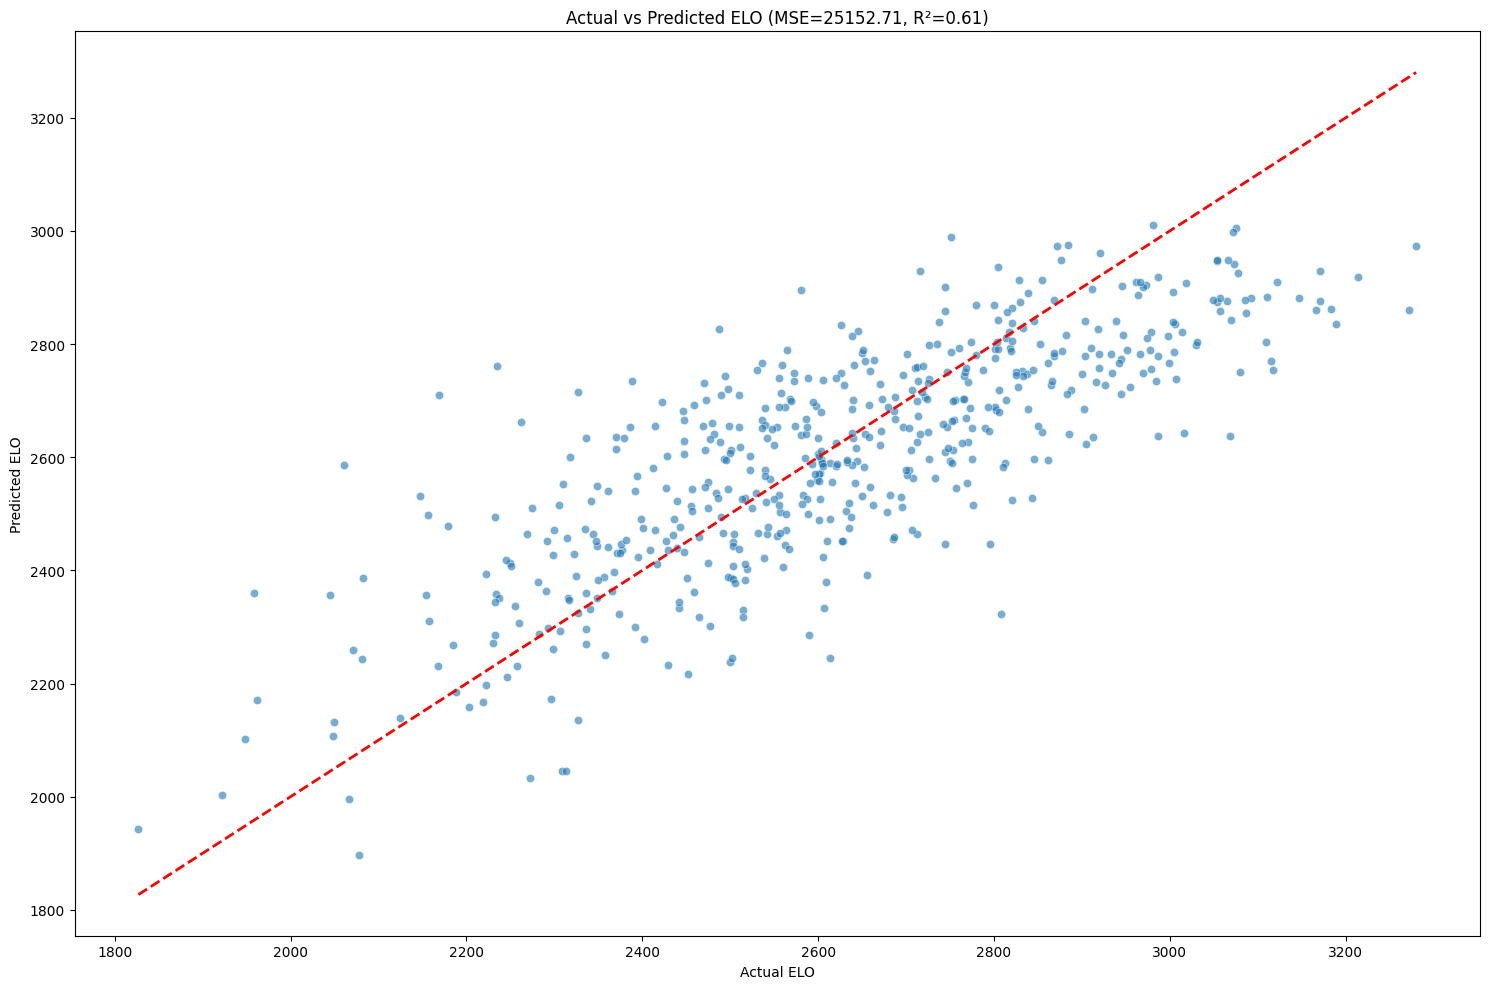

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

#理想线 (y=x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual ELO')
plt.ylabel('Predicted ELO')
plt.title(f'Actual vs Predicted ELO (MSE={mse:.2f}, R²={r2:.2f})')

plt.tight_layout()
plt.show()


In [41]:
from sklearn.ensemble import RandomForestRegressor

X = df[feature_cols].values  
y = df['ELO'].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


R2: 0.615315564133311
MSE: 25052.38566094886


In [42]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,      # L1
    reg_lambda=1.0,     # L2
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2: 0.6168678143239145
MSE: 24951.296126796882


LSTM